In [1]:
#import pandas as pd
import tangermeme
import bpnetlite

In [58]:
#df = pd.read_csv("/oak/stanford/groups/akundaje/anusri/chrombpnet_zenodo_uploads_reformatted/Variant_effect_prediction_benchmarking/cagi.mpra.per_model.scores.tsv", sep='\t')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "MIG-40f43250-998e-586a-ac37-d6520e92590f" 

from bpnetlite import BPNet

In [59]:
import pyfaidx
from tangermeme.utils import one_hot_encode
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute

# pos0=5271188
# chrm = 'chr11'
# SEQLEN=2114
# pos0=155271420
# chrm = 'chr1'
pos0=11200089
chrm = 'chr19'
SEQLEN=2114

genome = pyfaidx.Fasta("/mnt/lab_data2/anusri/chrombpnet/reference/male.hg19.fa")
seq = genome[chrm][pos0-SEQLEN//2:pos0+SEQLEN//2].seq.upper()
X = one_hot_encode(seq).unsqueeze(0).float()
X.shape

torch.Size([1, 4, 2114])

In [60]:
from tangermeme.ism import saturation_mutagenesis
import torch

class SliceWrapper(torch.nn.Module):
    def __init__(self, model):
        super(SliceWrapper, self).__init__()
        self.model = model

    def forward(self, X):
        return self.model(X)[1]
# models = [
# "/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/K562/nautilus_runs/K562_02.17.2022_bias_128_4_1234_0.5_fold_0/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_1_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_2_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_3_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_4_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5"
# ]

models = [
"/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/HEPG2/nautilus_runs_jun16/HEPG2_05.09.2022_bias_128_4_1234_0.8_fold_0/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_06.07.2022_bias_128_4_1234_0.8_fold_1/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_05.24.2022_bias_128_4_1234_0.8_fold_2/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_05.22.2022_bias_128_4_1234_0.8_fold_3/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_05.22.2022_bias_128_4_1234_0.8_fold_4/chrombpnet_model/chrombpnet_wo_bias.h5"
]


idx=0
for accessibility_model in models:
#accessibility_model="/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/DNASE_PE/K562/nautilus_runs_may18/K562_05.13.2022_bias_128_4_1234_0.5_fold_0/chrombpnet_model/chrombpnet_wo_bias.h5"
    acc = BPNet.from_chrombpnet(accessibility_model)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    #print(device)
    wrapper = SliceWrapper(acc)
    if idx==0:
        X_attr = saturation_mutagenesis(wrapper, X  , start=SEQLEN//2-150, end=SEQLEN//2+150,  device='cuda', hypothetical=True)
        idx+=1
    else:
        X_attr += saturation_mutagenesis(wrapper, X  , start=SEQLEN//2-150, end=SEQLEN//2+150,  device='cuda', hypothetical=True)

X_attr = X_attr/5

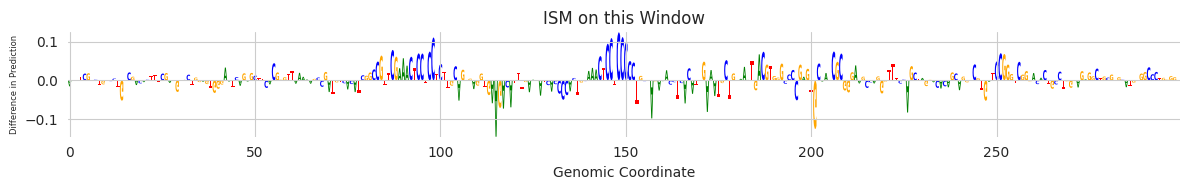

In [61]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo((X_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()

In [62]:
import numpy as np
outfile="chrombpnet_atac_LDLR.npy"
np.save(outfile, X_attr)


#X_attr.shape

In [63]:
from tangermeme.ism import saturation_mutagenesis
import torch

class SliceWrapper(torch.nn.Module):
    def __init__(self, model):
        super(SliceWrapper, self).__init__()
        self.model = model

    def forward(self, X):
        return self.model(X)[0]
# models = [
# "/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/K562/nautilus_runs/K562_02.17.2022_bias_128_4_1234_0.5_fold_0/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_1_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_2_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_3_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5",
# "/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/K562/K562_07.07.2022_bias_128_4_2356_0.5_fold_4_data_type_ATAC_PE/chrombpnet_model/chrombpnet_wo_bias.h5"
# ]
models = [
"/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/HEPG2/nautilus_runs_jun16/HEPG2_05.09.2022_bias_128_4_1234_0.8_fold_0/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_06.07.2022_bias_128_4_1234_0.8_fold_1/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_05.24.2022_bias_128_4_1234_0.8_fold_2/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_05.22.2022_bias_128_4_1234_0.8_fold_3/chrombpnet_model/chrombpnet_wo_bias.h5",
"/oak/stanford/groups/akundaje/projects/chromatin-atlas-2022/chrombpnet/folds/ATAC/HEPG2/HEPG2_05.22.2022_bias_128_4_1234_0.8_fold_4/chrombpnet_model/chrombpnet_wo_bias.h5"
]

idx=0
for accessibility_model in models:
#accessibility_model="/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/DNASE_PE/K562/nautilus_runs_may18/K562_05.13.2022_bias_128_4_1234_0.5_fold_0/chrombpnet_model/chrombpnet_wo_bias.h5"
    acc = BPNet.from_chrombpnet(accessibility_model)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    #print(device)
    wrapper = SliceWrapper(acc)
    if idx==0:
        X_attr = saturation_mutagenesis(wrapper, X  , start=SEQLEN//2-150, end=SEQLEN//2+150,  device='cuda', hypothetical=True)
        idx+=1
    else:
        X_attr += saturation_mutagenesis(wrapper, X  , start=SEQLEN//2-150, end=SEQLEN//2+150,  device='cuda', hypothetical=True)

X_attr = X_attr/5

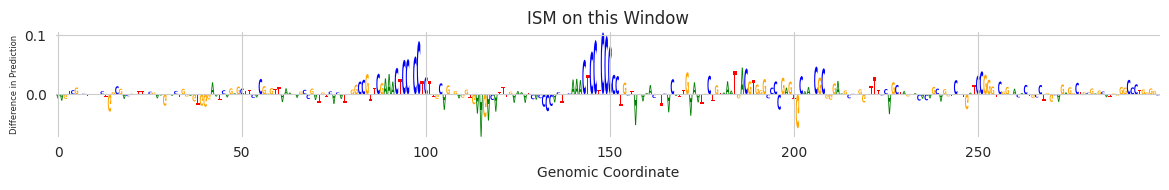

In [64]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo((X_attr * X[:, :, SEQLEN//2-150:SEQLEN//2+150])[0])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()

In [65]:
import numpy as np
outfile="chrombpnet_atac_profile_LDLR.npy"
np.save(outfile, X_attr)

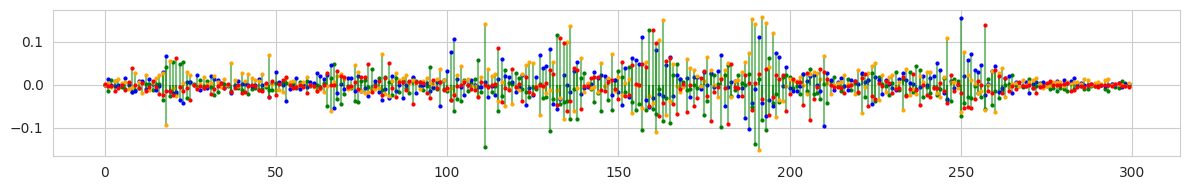

In [37]:
size=2
alpha_value = 0.5
green_with_alpha = [0, 0.5, 0, alpha_value]

c = [[0, 0.5, 0], [0, 0, 1], [1, 0.65, 0], [1, 0, 0]]
plt.figure(figsize=(12, 2))
(markerline, stemlines, baseline) = plt.stem(X_attr[0,0,:], linefmt='g-', markerfmt='o', basefmt=' ')
markerline.set_color(c[0])  # set the color of the bulbs
markerline.set_markersize(size)  # reduce bulb size
stemlines.set_color(green_with_alpha)

(markerline, stemlines, baseline) = plt.stem(X_attr[0,1,:], linefmt='g-', markerfmt='o', basefmt=' ')
markerline.set_color(c[1])  # set the color of the bulbs
markerline.set_markersize(size)  # reduce bulb size
stemlines.set_color(green_with_alpha)

(markerline, stemlines, baseline) = plt.stem(X_attr[0,2,:], linefmt='g-', markerfmt='o', basefmt=' ')
markerline.set_color(c[2])  # set the color of the bulbs
markerline.set_markersize(size)  # reduce bulb size
stemlines.set_color(green_with_alpha)

(markerline, stemlines, baseline) = plt.stem(X_attr[0,3,:], linefmt='g-', markerfmt='o', basefmt=' ')
markerline.set_color(c[3])  # set the color of the bulbs
markerline.set_markersize(size)  # reduce bulb size
stemlines.set_color(green_with_alpha)

plt.tight_layout()


# plt.stem(X_attr[0,1,:], color="b")
# plt.stem(X_attr[0,2,:], color="y")
# plt.stem(X_attr[0,3,:], color="r")


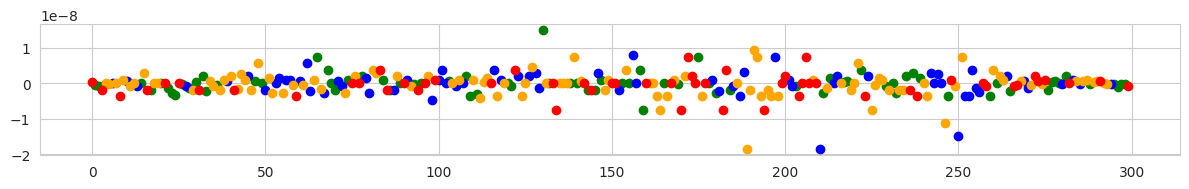

In [16]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_categorical_scatter

plt.figure(figsize=(12, 2))
plot_categorical_scatter((X_attr)[0])

# plt.xlabel("Genomic Coordinate")
# plt.ylabel("Difference in Prediction", fontsize=6)
# plt.title("ISM on this Window")

plt.tight_layout()
plt.show()

In [23]:
acct = acc.to('cpu')
#acct(X)[0].shape # 0 is profile

torch.Size([1, 1, 1000])

In [24]:
#acct(X)[1].shape

torch.Size([1, 1])

<Axes: >

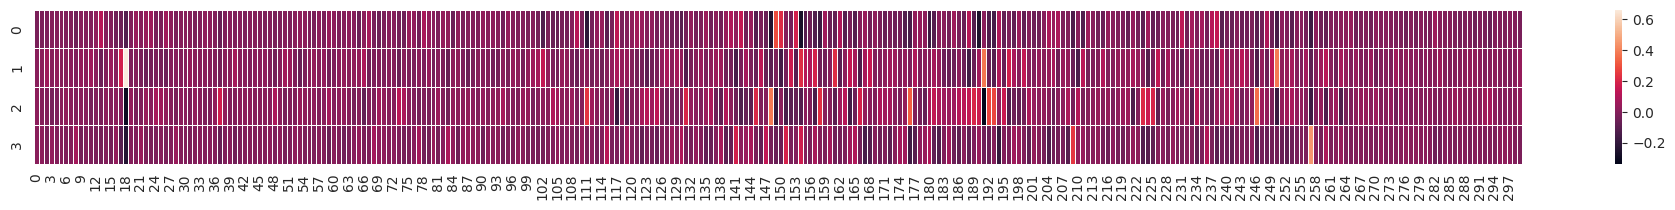

In [13]:
import seaborn as sns
plt.figure(figsize=(24, 2))

sns.heatmap(X_attr[0], linewidth=.5)


In [7]:
#y0.shape

In [63]:
#yhat.shape

In [64]:
# attr = yhat[:, :, :, None] - y0[:, None, None, None]
# attr -= torch.mean(attr, dim=1, keepdims=True)

In [8]:
# if len(attr.shape) > 3:
#     attr = torch.mean(attr, dim=tuple(range(3, len(attr.shape))))

In [9]:
# attr.shape

In [10]:
#X_attr=attr

In [13]:
#X_attr

In [26]:
import numpy as np
np.sum(np.isnan(X_attr).to(torch.int))

TypeError: sum() received an invalid combination of arguments - got (out=NoneType, axis=NoneType, ), but expected one of:
 * (*, torch.dtype dtype = None)
      didn't match because some of the keywords were incorrect: out, axis
 * (tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None)
 * (tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

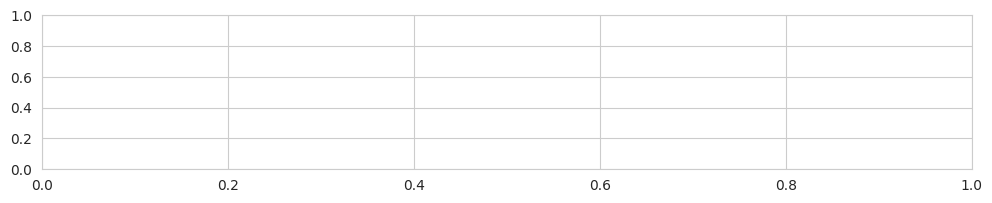

cuda


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

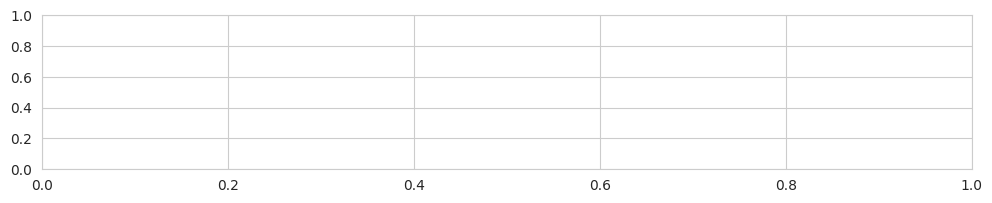

In [10]:
altallele="A"
seq = genome[chrm][pos0-SEQLEN//2:pos0].seq.upper() +altallele + genome[chrm][pos0+1:pos0+SEQLEN//2].seq.upper()
#seq = genome['chr11'][5271075-1057:5271075].seq.upper() + 'A' + genome['chr11'][5271075+1:5271075+1057].seq.upper()
X = one_hot_encode(seq).unsqueeze(0).float()
X.shape

class SliceWrapper(torch.nn.Module):
    def __init__(self, model):
        super(SliceWrapper, self).__init__()
        self.model = model

    def forward(self, X):
        return self.model(X)[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
wrapper = SliceWrapper(acc)
X_attr = saturation_mutagenesis(wrapper, X  , start=SEQLEN//2-100, end=SEQLEN//2+100,  device='cuda')
X_attr.shape



import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')
from tangermeme.plot import plot_logo

plt.figure(figsize=(12, 2))
plot_logo((X_attr * X[:, :, SEQLEN//2-100:SEQLEN//2+100])[0])

plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction", fontsize=6)
plt.title("ISM on this Window")

plt.tight_layout()
plt.show()